<a href="https://colab.research.google.com/github/tanvibeer12/Pattern-Recognition/blob/main/CM23020_pr_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import h5py
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving archive (3).zip to archive (3).zip


In [ ]:
import zipfile
import os

# Define the path to the uploaded zip file
zip_file_name = "archive (3).zip" # Based on the uploaded files

# Check if the zip file exists and extract its contents
if os.path.exists(zip_file_name):
    with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
        zip_ref.extractall() # Extracts all contents to the current directory
    print(f"'{zip_file_name}' extracted successfully.")
else:
    print(f"Error: '{zip_file_name}' not found. Please ensure it was uploaded.")

# Now, try to open the h5 file
with h5py.File("usps.h5", "r") as hf:

    train = hf.get("train")
    X_train = train.get("data")[:]
    y_train = train.get("target")[:]

    test = hf.get("test")
    X_test = test.get("data")[:]
    y_test = test.get("target")[:]

print("Training Images:", X_train.shape)
print("Testing Images:", X_test.shape)

'archive (3).zip' extracted successfully.
Training Images: (7291, 256)
Testing Images: (2007, 256)


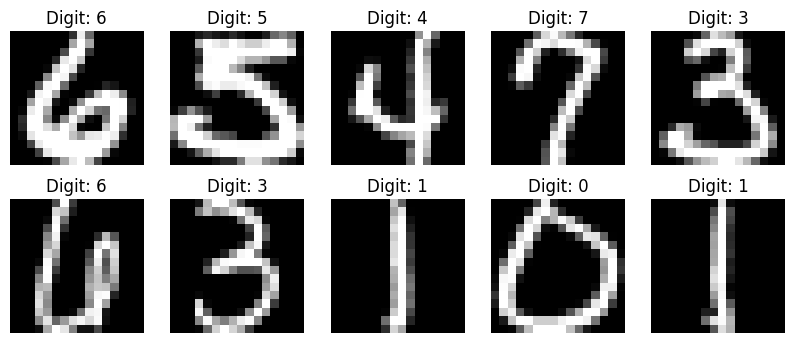

In [ ]:
plt.figure(figsize=(10,4))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i].reshape(16,16), cmap='gray')
    plt.title("Digit: {}".format(int(y_train[i])))
    plt.axis("off")

plt.show()

In [ ]:
def hu_features(images):

    features=[]

    for img in images:

        img=img.reshape(16,16)

        img=(img*255).astype(np.uint8)

        _,th=cv2.threshold(img,127,255,cv2.THRESH_BINARY)

        moments=cv2.moments(th)

        hu=cv2.HuMoments(moments).flatten()

        features.append(hu)

    return np.array(features)

X_train_hu=hu_features(X_train)

X_test_hu=hu_features(X_test)

print(X_train_hu.shape)

(7291, 7)


In [ ]:
svm=SVC(kernel='rbf')

svm.fit(X_train_hu,y_train)

pred_svm=svm.predict(X_test_hu)

print("SVM Accuracy :",accuracy_score(y_test,pred_svm))

SVM Accuracy : 0.22869955156950672


In [ ]:
print("KNN Report")

# Initialize, train, and predict with KNN model
knn = KNeighborsClassifier(n_neighbors=5) # Using 5 neighbors as a default, this can be tuned
knn.fit(X_train_hu, y_train)
pred_knn = knn.predict(X_test_hu)

print(classification_report(y_test,pred_knn))

print("SVM Report")

print(classification_report(y_test,pred_svm))

KNN Report
              precision    recall  f1-score   support

           0       0.26      0.54      0.35       359
           1       0.82      0.72      0.77       264
           2       0.15      0.17      0.16       198
           3       0.14      0.13      0.13       166
           4       0.17      0.11      0.13       200
           5       0.09      0.06      0.07       160
           6       0.10      0.07      0.08       170
           7       0.21      0.20      0.20       147
           8       0.18      0.09      0.12       166
           9       0.15      0.07      0.10       177

    accuracy                           0.27      2007
   macro avg       0.23      0.22      0.21      2007
weighted avg       0.26      0.27      0.25      2007

SVM Report
              precision    recall  f1-score   support

           0       0.20      0.88      0.33       359
           1       0.32      0.53      0.40       264
           2       0.00      0.00      0.00       198
  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


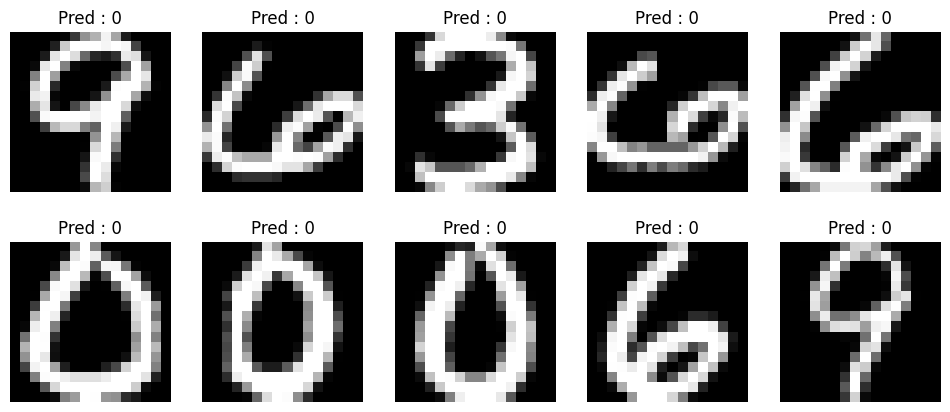

In [ ]:
plt.figure(figsize=(12,5))

for i in range(10):

    img=X_test[i].reshape(16,16)

    feature=hu_features([X_test[i]])

    prediction=svm.predict(feature)

    plt.subplot(2,5,i+1)

    plt.imshow(img,cmap='gray')

    plt.title("Pred : {}".format(int(prediction[0])))

    plt.axis('off')

plt.show()

In [ ]:
import cv2
import base64
import numpy as np
from google.colab import output
from IPython.display import display
from PIL import Image
import io
import matplotlib.pyplot as plt

def predict():
    data = eval_js("getCanvas()")

    encoded = data.split(',')[1]
    img = Image.open(io.BytesIO(base64.b64decode(encoded))).convert("L")

    img = np.array(img)

    img = 255 - img
    img = cv2.resize(img,(16,16))

    _,img = cv2.threshold(img,100,255,cv2.THRESH_BINARY)

    plt.imshow(img,cmap='gray')
    plt.axis('off')
    plt.show()

    moments = cv2.moments(img)
    feature = cv2.HuMoments(moments).flatten().reshape(1,-1)

    pred = svm.predict(feature)

    print("Predicted Digit:", int(pred[0]))

output.register_callback('notebook.predict', predict)